# Three-Lens IL Constraint Study (Fixed Object/Image Planes)

This notebook isolates the intermediate-lens (IL1, IL2, IL3) relay into a minimal model.

Goal: solve for focal lengths $f_1,f_2,f_3$ given:
1. fixed object plane and fixed image plane,
2. target magnification $A=M_{\mathrm{target}}$,
3. imaging condition $B=0$,
4. fixed total rotation demand from the three IL lenses: $\sum NI_i = NI_{\mathrm{target}}$.

We also add diagnostics for an optional zoom-like condition (no internal image before IL3).

## 1) Model and DOF Counting

The 2x2 ray matrix is
$$
M = P(d_{3i})L(f_3)P(d_{23})L(f_2)P(d_{12})L(f_1)P(d_{01})
$$
with
$$
P(d)=\begin{bmatrix}1&d\\0&1\end{bmatrix},\quad
L(f)=\begin{bmatrix}1&0\\-1/f&1\end{bmatrix}.
$$

Unknowns are $f_1,f_2,f_3$ (3 scalar unknowns).

Hard constraints:
- $A(M)=M_{\mathrm{target}}$ (magnification),
- $B(M)=0$ (image at fixed plane),
- $\sum_i NI_i = NI_{\mathrm{target}}$ with $NI_i=\sqrt{1/(G_i f_i)}$.

This is exactly 3 constraints for 3 unknowns, so generically solvable only on a feasible subset of targets/geometry.

If you *also* require an extra zoom-structure constraint, you usually over-constrain unless another variable is released (for example objective/image plane, or lens spacings).

In [15]:
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt

%matplotlib widget

In [16]:
# Example geometry and lens constants (taken from the microscope study).
geom = {
    'd01': 8.0e-3,    # object plane -> IL1
    'd12': 52.0e-3,   # IL1 -> IL2
    'd23': 62.0e-3,   # IL2 -> IL3
    'd3i': 48.75e-3,  # IL3 -> fixed image plane (pre-PL1 object plane)
}

Gc = {
    'IL1': 8.0e-6,
    'IL2': 8.0e-6,
    'IL3': 8.0e-6,
}

# Set NI target directly (equivalent to fixing theta/Rc).
# You can replace this with NI_target = theta_target / Rc_phys from your full notebook.
NI_target = 13735.0

# Target relay magnifications (IL section only):
M_targets = np.array([-10.0, -16.667, -33.333, -100.0, -200.0], dtype=float)

# Solve range for f3
f3_bounds = (1e-3, 80e-3)

## 2) Matrix Helpers

We use direct matrix composition for checks and compact closed forms for $f_1(M,f_3)$ and $f_2(M,f_3)$ from the fixed geometry + $A$ and $B=0$ structure.

In [17]:
def P(d):
    return np.array([[1.0, float(d)], [0.0, 1.0]], dtype=float)


def L(f):
    return np.array([[1.0, 0.0], [-1.0 / float(f), 1.0]], dtype=float)


def M_il(f1, f2, f3, g):
    return P(g['d3i']) @ L(f3) @ P(g['d23']) @ L(f2) @ P(g['d12']) @ L(f1) @ P(g['d01'])


def AB(M):
    return float(M[0, 0]), float(M[0, 1])


def f2_from_f3_A(f3, A_target, g):
    d01, d12, d23, d3i = g['d01'], g['d12'], g['d23'], g['d3i']
    num = d12 * (f3 * (d23 + d3i) - d23 * d3i)
    den = f3 * (A_target * d01 + d23 + d3i + d12) - d3i * (d23 + d12)
    if abs(den) < 1e-15:
        return np.nan
    return float(num / den)


def f1_from_f3_A(f3, A_target, g):
    d01, d12, d23, d3i = g['d01'], g['d12'], g['d23'], g['d3i']
    num = A_target * d01 * d12 * f3
    den = f3 * (A_target * (d01 + d12) + d23 + d3i) - d23 * d3i
    if abs(den) < 1e-15:
        return np.nan
    return float(num / den)


def NI_from_f(f, gc):
    if not np.isfinite(f) or f <= 0.0:
        return np.nan
    return float(np.sqrt(1.0 / (gc * f)))

## 3) Hard-Constraint Solver

For a fixed $M_{\mathrm{target}}$, unknowns reduce to one variable $f_3$:
- compute $f_1(f_3),f_2(f_3)$ from geometry + $A$,
- solve scalar residual $r(f_3)=NI_1+NI_2+NI_3-NI_{\mathrm{target}}=0$.

Then we validate:
- positivity of focal lengths,
- matrix checks for $A$ and $B$ (must be near target and 0),
- optional no-internal-image-before-IL3 condition.

In [18]:
def has_internal_image_before_il3(f1, f2, g, n_scan=1000, b_tol=1e-12):
    d01, d12, d23 = g['d01'], g['d12'], g['d23']
    z_end = d01 + d12 + d23
    eps = max(1e-9, 1e-6 * z_end)
    z_grid = np.linspace(eps, z_end - eps, int(n_scan))

    prev_b = None
    for z in z_grid:
        if z < d01:
            M = P(z)
        elif z < d01 + d12:
            M = P(z - d01) @ L(f1) @ P(d01)
        else:
            M = P(z - d01 - d12) @ L(f2) @ P(d12) @ L(f1) @ P(d01)

        b = float(M[0, 1])
        if abs(b) <= b_tol:
            return True
        if prev_b is not None and prev_b * b < 0.0:
            return True
        prev_b = b

    return False


def solve_for_target_mag(A_target, g, gc, ni_target, f3_min=1e-3, f3_max=80e-3, n_grid=4000):
    def triplet_from_f3(f3):
        f2 = f2_from_f3_A(f3, A_target, g)
        f1 = f1_from_f3_A(f3, A_target, g)
        return f1, f2, float(f3)

    def residual(f3):
        f1, f2, f3_ = triplet_from_f3(f3)
        if not np.all(np.isfinite([f1, f2, f3_])) or min(f1, f2, f3_) <= 0.0:
            return np.nan
        ni_sum = NI_from_f(f1, gc['IL1']) + NI_from_f(f2, gc['IL2']) + NI_from_f(f3_, gc['IL3'])
        return float(ni_sum - ni_target)

    f3_grid = np.geomspace(f3_min, f3_max, int(n_grid))
    r_grid = np.array([residual(x) for x in f3_grid], dtype=float)
    finite = np.isfinite(r_grid)
    if not np.any(finite):
        raise RuntimeError(f'No finite NI residual values for A={A_target:.5g}')

    g_f = f3_grid[finite]
    r_f = r_grid[finite]

    brackets = []
    for a, b, ra, rb in zip(g_f[:-1], g_f[1:], r_f[:-1], r_f[1:]):
        if ra == 0.0:
            brackets.append((float(a), float(a)))
        elif ra * rb < 0.0:
            brackets.append((float(a), float(b)))

    if not brackets:
        raise RuntimeError(f'No NI sign-change bracket for A={A_target:.5g}')

    # Try each bracket and keep the first physically valid solution.
    for a, b in brackets:
        if a == b:
            f3_star = float(a)
        else:
            try:
                f3_star = float(brentq(lambda x: residual(float(x)), a, b, maxiter=200))
            except ValueError:
                # Singular residual inside bracket; skip this bracket.
                continue

        f1_star, f2_star, f3_star = triplet_from_f3(f3_star)
        if min(f1_star, f2_star, f3_star) <= 0.0:
            continue

        M = M_il(f1_star, f2_star, f3_star, g)
        A_actual, B_actual = AB(M)

        ni1 = NI_from_f(f1_star, gc['IL1'])
        ni2 = NI_from_f(f2_star, gc['IL2'])
        ni3 = NI_from_f(f3_star, gc['IL3'])
        ni_sum = ni1 + ni2 + ni3

        return {
            'A_target': float(A_target),
            'A_actual': float(A_actual),
            'B_actual': float(B_actual),
            'f1_m': float(f1_star),
            'f2_m': float(f2_star),
            'f3_m': float(f3_star),
            'NI1': float(ni1),
            'NI2': float(ni2),
            'NI3': float(ni3),
            'NI_sum': float(ni_sum),
            'NI_err': float(ni_sum - ni_target),
            'internal_image_before_il3': bool(has_internal_image_before_il3(f1_star, f2_star, g)),
        }

    raise RuntimeError(f'Brackets exist but no physically valid root survived checks for A={A_target:.5g}')

In [19]:
rows = []
for A_t in M_targets:
    try:
        rows.append(solve_for_target_mag(A_t, geom, Gc, NI_target, *f3_bounds))
    except Exception as e:
        rows.append({
            'A_target': float(A_t),
            'error': str(e),
        })

for r in rows:
    if 'error' in r:
        print(f"A={r['A_target']:.4g}: FAIL -> {r['error']}")
    else:
        print(
            f"A={r['A_target']:.4g}: "
            f"f(mm)=({1e3*r['f1_m']:.3f}, {1e3*r['f2_m']:.3f}, {1e3*r['f3_m']:.3f}) | "
            f"A_actual={r['A_actual']:.6g} | B={r['B_actual']:.3e} m/rad | "
            f"NI_err={r['NI_err']:.3e} | internal_before_IL3={r['internal_image_before_il3']}"
        )

A=-10: f(mm)=(3.423, 25.551, 4.162) | A_actual=-10 | B=-1.943e-16 m/rad | NI_err=-4.333e-07 | internal_before_IL3=True
A=-16.67: f(mm)=(3.999, 25.047, 3.579) | A_actual=-16.667 | B=8.327e-17 m/rad | NI_err=1.983e-10 | internal_before_IL3=True
A=-33.33: f(mm)=(4.838, 23.703, 3.094) | A_actual=-33.333 | B=-5.551e-17 m/rad | NI_err=3.820e-11 | internal_before_IL3=True
A=-100: f(mm)=(5.990, 19.054, 2.865) | A_actual=-100 | B=0.000e+00 m/rad | NI_err=-3.765e-07 | internal_before_IL3=True
A=-200: f(mm)=(6.469, 13.886, 3.111) | A_actual=-200 | B=0.000e+00 m/rad | NI_err=2.110e-10 | internal_before_IL3=True


## 4) Optional Zoom-Like Diagnostics

A strict additional zoom condition usually costs one more constraint.

Useful practical checks (diagnostics, not hard equations):
- no internal image before IL3,
- smooth/monotonic trends of $f_2,f_3$ with target magnification,
- bounded current range for IL2/IL3.

If these are promoted to hard constraints, one existing hard condition normally must be relaxed, or another variable (e.g., spacing) introduced.

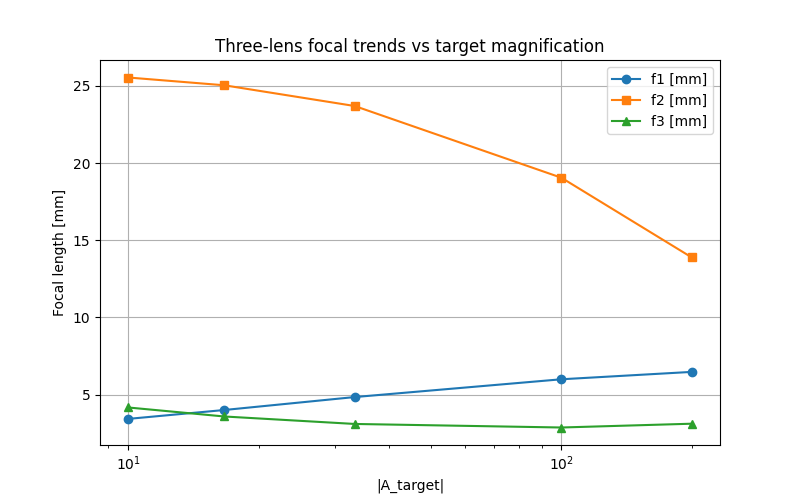

In [20]:
ok_rows = [r for r in rows if 'error' not in r]
if ok_rows:
    A = np.array([r['A_target'] for r in ok_rows], dtype=float)
    f1 = 1e3 * np.array([r['f1_m'] for r in ok_rows], dtype=float)
    f2 = 1e3 * np.array([r['f2_m'] for r in ok_rows], dtype=float)
    f3 = 1e3 * np.array([r['f3_m'] for r in ok_rows], dtype=float)

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    ax.semilogx(np.abs(A), f1, 'o-', label='f1 [mm]')
    ax.semilogx(np.abs(A), f2, 's-', label='f2 [mm]')
    ax.semilogx(np.abs(A), f3, '^-', label='f3 [mm]')
    ax.set_xlabel('|A_target|')
    ax.set_ylabel('Focal length [mm]')
    ax.set_title('Three-lens focal trends vs target magnification')
    ax.grid(True)
    ax.legend()
    plt.show()
else:
    print('No successful rows to plot.')

## 5) How To Enforce A Real Zoom Pair

To enforce "IL2+IL3 act as a zoom lens" as a **hard** requirement, choose one explicit extra condition, for example:
- fixed intermediate conjugate location for the IL2+IL3 subsystem, or
- fixed effective back focal distance of IL2+IL3, or
- explicit monotonic relation $f_2=f_2(\zeta), f_3=f_3(\zeta)$ with one zoom parameter $\zeta$.

Then adjust DOF by relaxing one current hard condition (or by adding an extra free variable such as lens spacing).

## 6) Recommended Constraint Hierarchy

If IL2 and IL3 are linked by a single zoom parameter $\zeta$, then the unknowns become effectively:
- $\zeta$ controlling the IL2/IL3 pair,
- $f_1$ as a compensator.

That leaves only 2 effective degrees of freedom, so only 2 constraints should remain hard.

Recommended hard constraints:
- target magnification $A = M_{\mathrm{target}}$,
- imaging condition $B = 0$ at the chosen plane.

Recommended relaxed constraint:
- do **not** require the IL stack alone to keep $NI_1 + NI_2 + NI_3$ exactly constant.

Reason:
- magnification and imaging are the primary optical function of the relay,
- exact rotation cancellation is a secondary compensation requirement,
- in a real microscope, residual rotation is usually easier to absorb elsewhere than a broken image condition.

Most realistic ways to absorb that residual rotation are:
- let ObjPost and/or PL1 take up the rotation compensation instead of forcing the IL trio to do it exactly,
- allow a small tolerance band on total rotation instead of exact equality,
- calibrate residual rotation out in the operating curve rather than deriving it as a hard first-principles constraint.

If you insist on a true IL2+IL3 zoom pair as a hard structural condition, then the practical formulation is:
- prescribe $f_2 = f_2(\zeta)$ and $f_3 = f_3(\zeta)$,
- solve $(\zeta, f_1)$ from $A$ and $B=0$,
- treat total rotation as an output to be compensated elsewhere.

Less desirable constraints to relax:
- target magnification: usually this is the point of the mode,
- object plane location: this couples back upstream and is not a clean local relaxation,
- exact image plane at the IL output: possible to relax only if PL1 is explicitly allowed to refocus it.

So the practical order is:
1. Keep $A$ hard.
2. Keep imaging hard.
3. Link IL2/IL3 by a zoom law.
4. Relax exact IL-only rotation closure.

## 7) Achievable Magnification Family With Hard $B=0$ And Hard Rotation

This is the alternative formulation you suggested.

Here we keep hard:
- image condition $B=0$,
- total rotation $NI_1 + NI_2 + NI_3 = NI_{\mathrm{target}}$.

We do **not** prescribe magnification.
Instead, magnification $A$ becomes an output of the admissible solution family.

That means:
- 3 unknowns: $f_1,f_2,f_3$,
- 2 hard constraints: $B=0$ and fixed total rotation,
- therefore a 1-parameter family of solutions should exist when geometry is feasible.

A practical way to trace that family is to:
- choose $f_3$ as the continuation parameter,
- solve for $(f_1,f_2)$ from the two hard equations,
- read out $A$ as the resulting achievable magnification.

This gives the natural magnification range available while preserving the two hard constraints.

In [21]:
from scipy.optimize import root


def solve_f1_f2_for_fixed_f3(f3_fixed, g, gc, ni_target, initial_guess):
    def residuals(vec):
        f1_trial, f2_trial = map(float, vec)
        if min(f1_trial, f2_trial, f3_fixed) <= 0.0:
            return np.array([1e6, 1e6], dtype=float)

        M = M_il(f1_trial, f2_trial, f3_fixed, g)
        A_actual, B_actual = AB(M)
        ni_sum = (
            NI_from_f(f1_trial, gc['IL1'])
            + NI_from_f(f2_trial, gc['IL2'])
            + NI_from_f(f3_fixed, gc['IL3'])
        )
        return np.array([
            float(B_actual),
            float(ni_sum - ni_target),
        ], dtype=float)

    sol = root(residuals, x0=np.array(initial_guess, dtype=float), method='hybr')
    if not sol.success:
        return None

    f1_star, f2_star = map(float, sol.x)
    if min(f1_star, f2_star, f3_fixed) <= 0.0:
        return None

    M = M_il(f1_star, f2_star, f3_fixed, g)
    A_actual, B_actual = AB(M)
    ni1 = NI_from_f(f1_star, gc['IL1'])
    ni2 = NI_from_f(f2_star, gc['IL2'])
    ni3 = NI_from_f(f3_fixed, gc['IL3'])
    ni_sum = ni1 + ni2 + ni3

    if abs(B_actual) > 1e-8:
        return None
    if abs(ni_sum - ni_target) > 1e-3:
        return None

    return {
        'f1_m': float(f1_star),
        'f2_m': float(f2_star),
        'f3_m': float(f3_fixed),
        'A_actual': float(A_actual),
        'B_actual': float(B_actual),
        'NI_sum': float(ni_sum),
        'NI_err': float(ni_sum - ni_target),
        'internal_image_before_il3': bool(has_internal_image_before_il3(f1_star, f2_star, g)),
    }


def trace_constant_rotation_family(g, gc, ni_target, f3_values, seed_guesses_mm=(3.0, 5.0, 8.0, 12.0, 20.0)):
    family_rows = []
    prev_guess = None

    base_guesses = [(a * 1e-3, b * 1e-3) for a in seed_guesses_mm for b in seed_guesses_mm]

    for f3_fixed in np.asarray(f3_values, dtype=float):
        guess_list = []
        if prev_guess is not None:
            guess_list.append(prev_guess)
        guess_list.extend(base_guesses)

        best = None
        for guess in guess_list:
            cand = solve_f1_f2_for_fixed_f3(float(f3_fixed), g, gc, ni_target, guess)
            if cand is None:
                continue
            best = cand
            prev_guess = (cand['f1_m'], cand['f2_m'])
            break

        if best is not None:
            family_rows.append(best)

    return family_rows


f3_family_scan = np.geomspace(1.5e-3, 80e-3, 220)
family_rows = trace_constant_rotation_family(geom, Gc, NI_target, f3_family_scan)

print(f'Found {len(family_rows)} admissible family points with hard B=0 and hard rotation.')
if family_rows:
    A_vals = np.array([r['A_actual'] for r in family_rows], dtype=float)
    no_internal = np.array([not r['internal_image_before_il3'] for r in family_rows], dtype=bool)

    print(
        f"All family points: A in [{np.min(A_vals):.6g}, {np.max(A_vals):.6g}]"
    )
    if np.any(no_internal):
        A_zoom = A_vals[no_internal]
        print(
            f"No-internal-image subset: A in [{np.min(A_zoom):.6g}, {np.max(A_zoom):.6g}]"
        )
    else:
        print('No family points satisfy the no-internal-image-before-IL3 diagnostic.')
else:
    print('No admissible family points found for this geometry and NI target.')

Found 196 admissible family points with hard B=0 and hard rotation.
All family points: A in [-394.563, 245.247]
No family points satisfy the no-internal-image-before-IL3 diagnostic.


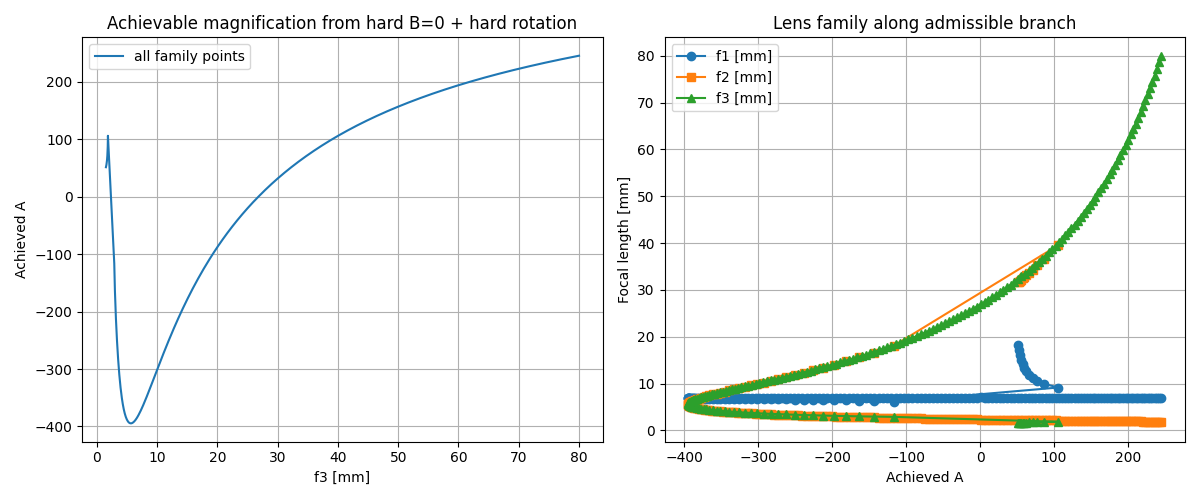

In [22]:
if family_rows:
    f1_family = 1e3 * np.array([r['f1_m'] for r in family_rows], dtype=float)
    f2_family = 1e3 * np.array([r['f2_m'] for r in family_rows], dtype=float)
    f3_family = 1e3 * np.array([r['f3_m'] for r in family_rows], dtype=float)
    A_family = np.array([r['A_actual'] for r in family_rows], dtype=float)
    zoom_ok = np.array([not r['internal_image_before_il3'] for r in family_rows], dtype=bool)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].plot(f3_family, A_family, '-', lw=1.5, label='all family points')
    if np.any(zoom_ok):
        axs[0].plot(f3_family[zoom_ok], A_family[zoom_ok], 'o', ms=3, label='no internal image before IL3')
    axs[0].set_xlabel('f3 [mm]')
    axs[0].set_ylabel('Achieved A')
    axs[0].set_title('Achievable magnification from hard B=0 + hard rotation')
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(A_family, f1_family, 'o-', label='f1 [mm]')
    axs[1].plot(A_family, f2_family, 's-', label='f2 [mm]')
    axs[1].plot(A_family, f3_family, '^-', label='f3 [mm]')
    axs[1].set_xlabel('Achieved A')
    axs[1].set_ylabel('Focal length [mm]')
    axs[1].set_title('Lens family along admissible branch')
    axs[1].grid(True)
    axs[1].legend()

    fig.tight_layout()
    plt.show()
else:
    print('No family to plot.')

In [23]:
def first_pre_il3_image_location(f1, f2, g, n_scan=2000, b_tol=1e-12):
    d01, d12, d23 = g['d01'], g['d12'], g['d23']
    z_end = d01 + d12 + d23
    eps = max(1e-9, 1e-6 * z_end)
    z_grid = np.linspace(eps, z_end - eps, int(n_scan))

    prev_z = None
    prev_b = None
    for z in z_grid:
        if z < d01:
            M = P(z)
        elif z < d01 + d12:
            M = P(z - d01) @ L(f1) @ P(d01)
        else:
            M = P(z - d01 - d12) @ L(f2) @ P(d12) @ L(f1) @ P(d01)

        b = float(M[0, 1])
        if abs(b) <= b_tol:
            z_cross = float(z)
            break
        if prev_b is not None and prev_b * b < 0.0:
            frac = abs(prev_b) / (abs(prev_b) + abs(b))
            z_cross = float(prev_z + frac * (z - prev_z))
            break
        prev_z = z
        prev_b = b
    else:
        return None

    if z_cross < d01:
        region = 'before_IL1'
    elif z_cross < d01 + d12:
        region = 'between_IL1_IL2'
    else:
        region = 'between_IL2_IL3'
    return {'z_cross_m': z_cross, 'region': region}


family_crossings = []
for row in family_rows:
    cross = first_pre_il3_image_location(row['f1_m'], row['f2_m'], geom)
    if cross is None:
        family_crossings.append({'region': 'none'})
    else:
        family_crossings.append(cross)

regions = [r['region'] for r in family_crossings]
print('Pre-IL3 image crossing regions across admissible family:')
for region in ['before_IL1', 'between_IL1_IL2', 'between_IL2_IL3', 'none']:
    print(region, regions.count(region))

if any(r.get('region') == 'between_IL2_IL3' for r in family_crossings):
    zvals_mm = [1e3 * r['z_cross_m'] for r in family_crossings if r.get('region') == 'between_IL2_IL3']
    print(f'IL2->IL3 crossings exist, z range = [{min(zvals_mm):.3f}, {max(zvals_mm):.3f}] mm from object plane')
else:
    print('No crossings found specifically between IL2 and IL3.')

Pre-IL3 image crossing regions across admissible family:
before_IL1 0
between_IL1_IL2 183
between_IL2_IL3 13
none 0
IL2->IL3 crossings exist, z range = [61.925, 120.452] mm from object plane


Solutions with no image between IL2 and IL3: 183/196
Achievable A range on this subset: [-394.563, 245.247]
Sample candidate solutions:
A=-116.48 | f(mm)=(6.113, 18.078, 2.884) | B=-8.138e-12 | NI_err=-8.051e-09
A=-386.799 | f(mm)=(6.830, 4.841, 6.529) | B=-2.401e-11 | NI_err=-3.638e-12
A=-177.514 | f(mm)=(6.875, 2.879, 15.052) | B=-7.039e-14 | NI_err=-1.819e-12
A=70.3151 | f(mm)=(6.895, 2.176, 34.701) | B=-2.220e-15 | NI_err=-1.819e-12
A=245.247 | f(mm)=(6.899, 1.846, 80.000) | B=2.220e-16 | NI_err=3.638e-12


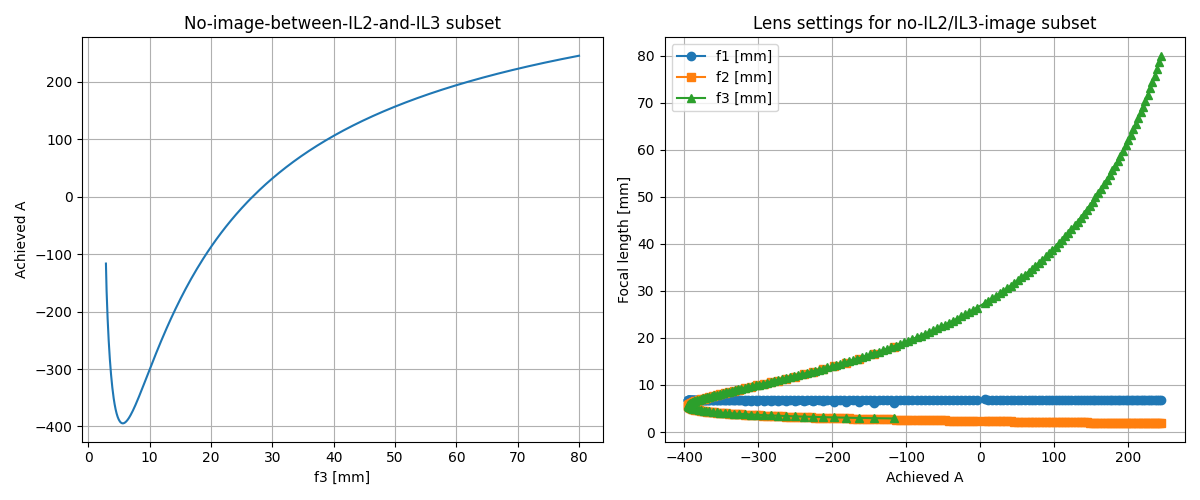

In [24]:
family_rows_no_il2_il3_image = [
    row for row, cross in zip(family_rows, family_crossings)
    if cross.get('region') != 'between_IL2_IL3'
]

print(f'Solutions with no image between IL2 and IL3: {len(family_rows_no_il2_il3_image)}/{len(family_rows)}')

if family_rows_no_il2_il3_image:
    A_no_il2_il3 = np.array([r['A_actual'] for r in family_rows_no_il2_il3_image], dtype=float)
    f1_no_il2_il3 = 1e3 * np.array([r['f1_m'] for r in family_rows_no_il2_il3_image], dtype=float)
    f2_no_il2_il3 = 1e3 * np.array([r['f2_m'] for r in family_rows_no_il2_il3_image], dtype=float)
    f3_no_il2_il3 = 1e3 * np.array([r['f3_m'] for r in family_rows_no_il2_il3_image], dtype=float)

    print(f"Achievable A range on this subset: [{np.min(A_no_il2_il3):.6g}, {np.max(A_no_il2_il3):.6g}]")
    print('Sample candidate solutions:')

    sample_idx = np.unique(np.linspace(0, len(family_rows_no_il2_il3_image) - 1, min(5, len(family_rows_no_il2_il3_image)), dtype=int))
    for idx in sample_idx:
        r = family_rows_no_il2_il3_image[int(idx)]
        print(
            f"A={r['A_actual']:.6g} | "
            f"f(mm)=({1e3*r['f1_m']:.3f}, {1e3*r['f2_m']:.3f}, {1e3*r['f3_m']:.3f}) | "
            f"B={r['B_actual']:.3e} | NI_err={r['NI_err']:.3e}"
        )

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].plot(f3_no_il2_il3, A_no_il2_il3, '-', lw=1.5)
    axs[0].set_xlabel('f3 [mm]')
    axs[0].set_ylabel('Achieved A')
    axs[0].set_title('No-image-between-IL2-and-IL3 subset')
    axs[0].grid(True)

    axs[1].plot(A_no_il2_il3, f1_no_il2_il3, 'o-', label='f1 [mm]')
    axs[1].plot(A_no_il2_il3, f2_no_il2_il3, 's-', label='f2 [mm]')
    axs[1].plot(A_no_il2_il3, f3_no_il2_il3, '^-', label='f3 [mm]')
    axs[1].set_xlabel('Achieved A')
    axs[1].set_ylabel('Focal length [mm]')
    axs[1].set_title('Lens settings for no-IL2/IL3-image subset')
    axs[1].grid(True)
    axs[1].legend()
    fig.tight_layout()
    plt.show()
else:
    print('No admissible solutions remain after excluding images between IL2 and IL3.')

In [25]:
def solve_for_target_mag_prefer_weak_f3_no_il2_il3(A_target, g, gc, ni_target, f3_min=1e-3, f3_max=80e-3, n_grid=4000):
    def triplet_from_f3(f3):
        f2 = f2_from_f3_A(f3, A_target, g)
        f1 = f1_from_f3_A(f3, A_target, g)
        return f1, f2, float(f3)

    def residual(f3):
        f1, f2, f3_ = triplet_from_f3(f3)
        if not np.all(np.isfinite([f1, f2, f3_])) or min(f1, f2, f3_) <= 0.0:
            return np.nan
        ni_sum = NI_from_f(f1, gc['IL1']) + NI_from_f(f2, gc['IL2']) + NI_from_f(f3_, gc['IL3'])
        return float(ni_sum - ni_target)

    f3_grid = np.geomspace(f3_min, f3_max, int(n_grid))
    r_grid = np.array([residual(x) for x in f3_grid], dtype=float)
    finite = np.isfinite(r_grid)
    if not np.any(finite):
        return None

    g_f = f3_grid[finite]
    r_f = r_grid[finite]
    brackets = []
    for a, b, ra, rb in zip(g_f[:-1], g_f[1:], r_f[:-1], r_f[1:]):
        if ra == 0.0:
            brackets.append((float(a), float(a)))
        elif ra * rb < 0.0:
            brackets.append((float(a), float(b)))

    candidates = []
    for a, b in brackets:
        if a == b:
            f3_star = float(a)
        else:
            try:
                f3_star = float(brentq(lambda x: residual(float(x)), a, b, maxiter=200))
            except ValueError:
                continue

        f1_star, f2_star, f3_star = triplet_from_f3(f3_star)
        if min(f1_star, f2_star, f3_star) <= 0.0:
            continue

        M = M_il(f1_star, f2_star, f3_star, g)
        A_actual, B_actual = AB(M)
        if abs(B_actual) > 1e-8:
            continue

        cross = first_pre_il3_image_location(f1_star, f2_star, g)
        if cross is not None and cross['region'] == 'between_IL2_IL3':
            continue

        ni1 = NI_from_f(f1_star, gc['IL1'])
        ni2 = NI_from_f(f2_star, gc['IL2'])
        ni3 = NI_from_f(f3_star, gc['IL3'])
        ni_sum = ni1 + ni2 + ni3
        if abs(ni_sum - ni_target) > 1e-3:
            continue

        candidates.append({
            'A_target': float(A_target),
            'A_actual': float(A_actual),
            'f1_m': float(f1_star),
            'f2_m': float(f2_star),
            'f3_m': float(f3_star),
            'B_actual': float(B_actual),
        })

    if not candidates:
        return None

    candidates.sort(key=lambda row: row['f3_m'], reverse=True)
    return candidates[0]


def sweep_d01_for_target_family(d01_values_mm, mag_targets):
    rows = []
    for d01_mm in np.asarray(d01_values_mm, dtype=float):
        g = dict(geom)
        g['d01'] = float(d01_mm) * 1e-3

        sols = []
        for A_target in np.asarray(mag_targets, dtype=float):
            sol = solve_for_target_mag_prefer_weak_f3_no_il2_il3(A_target, g, Gc, NI_target)
            if sol is None:
                sols = None
                break
            sols.append(sol)

        if sols is None:
            rows.append({
                'd01_mm': float(d01_mm),
                'feasible': False,
            })
            continue

        rows.append({
            'd01_mm': float(d01_mm),
            'feasible': True,
            'f1_mean_mm': float(np.mean([1e3 * s['f1_m'] for s in sols])),
            'f2_mean_mm': float(np.mean([1e3 * s['f2_m'] for s in sols])),
            'f3_mean_mm': float(np.mean([1e3 * s['f3_m'] for s in sols])),
            'f1_min_mm': float(np.min([1e3 * s['f1_m'] for s in sols])),
            'f2_min_mm': float(np.min([1e3 * s['f2_m'] for s in sols])),
            'f3_min_mm': float(np.min([1e3 * s['f3_m'] for s in sols])),
        })
    return rows


d01_sweep_mm = np.array([3, 5, 8, 10, 12, 15, 20, 25], dtype=float)
d01_rows = sweep_d01_for_target_family(d01_sweep_mm, M_targets)
for row in d01_rows:
    if not row['feasible']:
        print(f"d01={row['d01_mm']:.1f} mm | infeasible for at least one target")
    else:
        print(
            f"d01={row['d01_mm']:.1f} mm | "
            f"mean f1={row['f1_mean_mm']:.2f} mm, mean f2={row['f2_mean_mm']:.2f} mm, mean f3={row['f3_mean_mm']:.2f} mm | "
            f"min f1={row['f1_min_mm']:.2f} mm, min f2={row['f2_min_mm']:.2f} mm"
        )

d01=3.0 mm | infeasible for at least one target
d01=5.0 mm | mean f1=4.52 mm, mean f2=3.43 mm, mean f3=21.97 mm | min f1=4.51 mm, min f2=3.18 mm
d01=8.0 mm | mean f1=6.87 mm, mean f2=2.55 mm, mean f3=21.67 mm | min f1=6.86 mm, min f2=2.36 mm
d01=10.0 mm | mean f1=8.31 mm, mean f2=2.31 mm, mean f3=21.29 mm | min f1=8.30 mm, min f2=2.13 mm
d01=12.0 mm | mean f1=9.66 mm, mean f2=2.17 mm, mean f3=20.90 mm | min f1=9.65 mm, min f2=1.99 mm
d01=15.0 mm | mean f1=11.52 mm, mean f2=2.04 mm, mean f3=20.31 mm | min f1=11.51 mm, min f2=1.84 mm
d01=20.0 mm | mean f1=14.27 mm, mean f2=1.93 mm, mean f3=19.38 mm | min f1=14.24 mm, min f2=1.71 mm
d01=25.0 mm | mean f1=16.66 mm, mean f2=1.89 mm, mean f3=18.53 mm | min f1=16.59 mm, min f2=1.63 mm


In [26]:
def sweep_single_geometry_parameter(base_geom, key, values_mm, mag_targets):
    out = []
    for val_mm in np.asarray(values_mm, dtype=float):
        g = dict(base_geom)
        g[key] = float(val_mm) * 1e-3
        sols = []
        for A_target in np.asarray(mag_targets, dtype=float):
            sol = solve_for_target_mag_prefer_weak_f3_no_il2_il3(A_target, g, Gc, NI_target)
            if sol is None:
                sols = None
                break
            sols.append(sol)
        if sols is None:
            out.append((float(val_mm), None, None))
        else:
            out.append((
                float(val_mm),
                float(np.mean([1e3 * s['f1_m'] for s in sols])),
                float(np.mean([1e3 * s['f2_m'] for s in sols])),
            ))
    return out


d12_sweep = sweep_single_geometry_parameter(geom, 'd12', [40, 52, 65, 80], M_targets)
d23_sweep = sweep_single_geometry_parameter(geom, 'd23', [45, 62, 80, 100], M_targets)

print('d12 sweep (IL1->IL2 spacing):')
for val, f1m, f2m in d12_sweep:
    if f1m is None:
        print(f'  d12={val:.1f} mm | infeasible')
    else:
        print(f'  d12={val:.1f} mm | mean f1={f1m:.2f} mm, mean f2={f2m:.2f} mm')

print('d23 sweep (IL2->IL3 spacing):')
for val, f1m, f2m in d23_sweep:
    if f1m is None:
        print(f'  d23={val:.1f} mm | infeasible')
    else:
        print(f'  d23={val:.1f} mm | mean f1={f1m:.2f} mm, mean f2={f2m:.2f} mm')

d12 sweep (IL1->IL2 spacing):
  d12=40.0 mm | mean f1=6.57 mm, mean f2=2.74 mm
  d12=52.0 mm | mean f1=6.87 mm, mean f2=2.55 mm
  d12=65.0 mm | mean f1=7.08 mm, mean f2=2.45 mm
  d12=80.0 mm | mean f1=7.25 mm, mean f2=2.38 mm
d23 sweep (IL2->IL3 spacing):
  d23=45.0 mm | mean f1=6.86 mm, mean f2=2.84 mm
  d23=62.0 mm | mean f1=6.87 mm, mean f2=2.55 mm
  d23=80.0 mm | mean f1=6.88 mm, mean f2=2.41 mm
  d23=100.0 mm | mean f1=6.88 mm, mean f2=2.33 mm


In [27]:
def sweep_d3i_for_target_family(d3i_values_mm, mag_targets):
    rows = []
    for d3i_mm in np.asarray(d3i_values_mm, dtype=float):
        g = dict(geom)
        g['d3i'] = float(d3i_mm) * 1e-3

        sols = []
        for A_target in np.asarray(mag_targets, dtype=float):
            sol = solve_for_target_mag_prefer_weak_f3_no_il2_il3(A_target, g, Gc, NI_target)
            if sol is None:
                sols = None
                break
            sols.append(sol)

        if sols is None:
            rows.append((float(d3i_mm), None, None))
        else:
            rows.append((
                float(d3i_mm),
                float(np.mean([1e3 * s['f1_m'] for s in sols])),
                float(np.mean([1e3 * s['f2_m'] for s in sols])),
            ))
    return rows


def summarize_target_set(label, mag_targets):
    sols = []
    for A_target in np.asarray(mag_targets, dtype=float):
        sol = solve_for_target_mag_prefer_weak_f3_no_il2_il3(A_target, geom, Gc, NI_target)
        if sol is None:
            print(f'{label}: infeasible')
            return
        sols.append(sol)
    print(
        f"{label}: mean f1={np.mean([1e3*s['f1_m'] for s in sols]):.2f} mm, "
        f"mean f2={np.mean([1e3*s['f2_m'] for s in sols]):.2f} mm, "
        f"min f2={np.min([1e3*s['f2_m'] for s in sols]):.2f} mm"
    )


d3i_sweep = sweep_d3i_for_target_family([35, 48.75, 60, 80, 100], M_targets)
print('d3i sweep (IL3 -> image plane distance):')
for val, f1m, f2m in d3i_sweep:
    if f1m is None:
        print(f'  d3i={val:.2f} mm | infeasible')
    else:
        print(f'  d3i={val:.2f} mm | mean f1={f1m:.2f} mm, mean f2={f2m:.2f} mm')

summarize_target_set('Current targets', M_targets)
summarize_target_set('Without highest target', np.array([-10.0, -16.667, -33.333, -100.0], dtype=float))
summarize_target_set('Lower-mag subset', np.array([-10.0, -16.667, -33.333], dtype=float))

d3i sweep (IL3 -> image plane distance):
  d3i=35.00 mm | mean f1=6.87 mm, mean f2=2.86 mm
  d3i=48.75 mm | mean f1=6.87 mm, mean f2=2.55 mm
  d3i=60.00 mm | mean f1=6.88 mm, mean f2=2.42 mm
  d3i=80.00 mm | mean f1=6.87 mm, mean f2=2.30 mm
  d3i=100.00 mm | mean f1=6.87 mm, mean f2=2.23 mm
Current targets: mean f1=6.87 mm, mean f2=2.55 mm, min f2=2.36 mm
Without highest target: mean f1=6.87 mm, mean f2=2.44 mm, min f2=2.36 mm
Lower-mag subset: mean f1=6.87 mm, mean f2=2.39 mm, min f2=2.36 mm


In [28]:
print('='*70)
print('FOCAL LENGTH CONSTRAINT: f2 >= 5.0 mm')
print('='*70)

# Modified solver that enforces f2 >= 5.0 mm
def solve_for_target_mag_f2_floor(A_target, g, gc, ni_target, f2_min_mm=5.0, f3_min=1e-3, f3_max=80e-3, n_grid=4000):
    f2_floor = f2_min_mm * 1e-3
    
    def triplet_from_f3(f3):
        f2 = f2_from_f3_A(f3, A_target, g)
        f1 = f1_from_f3_A(f3, A_target, g)
        return f1, f2, float(f3)

    def residual(f3):
        f1, f2, f3_ = triplet_from_f3(f3)
        if not np.all(np.isfinite([f1, f2, f3_])) or min(f1, f2, f3_) <= 0.0:
            return np.nan
        # Reject if f2 is too small
        if f2 < f2_floor:
            return np.nan
        ni_sum = NI_from_f(f1, gc['IL1']) + NI_from_f(f2, gc['IL2']) + NI_from_f(f3_, gc['IL3'])
        return float(ni_sum - ni_target)

    f3_grid = np.geomspace(f3_min, f3_max, int(n_grid))
    r_grid = np.array([residual(x) for x in f3_grid], dtype=float)
    finite = np.isfinite(r_grid)
    if not np.any(finite):
        return None

    g_f = f3_grid[finite]
    r_f = r_grid[finite]
    brackets = []
    for a, b, ra, rb in zip(g_f[:-1], g_f[1:], r_f[:-1], r_f[1:]):
        if ra == 0.0:
            brackets.append((float(a), float(a)))
        elif ra * rb < 0.0:
            brackets.append((float(a), float(b)))

    candidates = []
    for a, b in brackets:
        if a == b:
            f3_star = float(a)
        else:
            try:
                f3_star = float(brentq(lambda x: residual(float(x)), a, b, maxiter=200))
            except ValueError:
                continue

        f1_star, f2_star, f3_star = triplet_from_f3(f3_star)
        if min(f1_star, f2_star, f3_star) <= 0.0 or f2_star < f2_floor:
            continue

        M = M_il(f1_star, f2_star, f3_star, g)
        A_actual, B_actual = AB(M)
        if abs(B_actual) > 1e-8:
            continue

        cross = first_pre_il3_image_location(f1_star, f2_star, g)
        if cross is not None and cross['region'] == 'between_IL2_IL3':
            continue

        ni1 = NI_from_f(f1_star, gc['IL1'])
        ni2 = NI_from_f(f2_star, gc['IL2'])
        ni3 = NI_from_f(f3_star, gc['IL3'])
        ni_sum = ni1 + ni2 + ni3
        if abs(ni_sum - ni_target) > 1e-3:
            continue

        candidates.append({
            'A_target': float(A_target),
            'A_actual': float(A_actual),
            'f1_m': float(f1_star),
            'f2_m': float(f2_star),
            'f3_m': float(f3_star),
            'B_actual': float(B_actual),
        })

    if not candidates:
        return None

    candidates.sort(key=lambda row: row['f3_m'], reverse=True)
    return candidates[0]


# Test each magnification target with f2 >= 5 mm constraint
print('\nTesting each magnification target with f2 >= 5.0 mm:')
print('-' * 70)
f2_constrained_results = {}
for A_target in M_targets:
    sol = solve_for_target_mag_f2_floor(A_target, geom, Gc, NI_target, f2_min_mm=5.0)
    if sol is None:
        print(f'  A={A_target:7.0f}: INFEASIBLE (no solution with f2 >= 5.0 mm)')
        f2_constrained_results[A_target] = None
    else:
        f2_constrained_results[A_target] = sol
        print(f'  A={A_target:7.0f}: f1={sol["f1_m"]*1e3:6.2f} mm, f2={sol["f2_m"]*1e3:6.2f} mm, f3={sol["f3_m"]*1e3:6.2f} mm')

feasible_with_f2 = [m for m, sol in f2_constrained_results.items() if sol is not None]
print(f'\nFeasible magnifications: {feasible_with_f2}')
print(f'Total: {len(feasible_with_f2)}/{len(M_targets)} targets')

if len(feasible_with_f2) < len(M_targets):
    print('\n⚠️  Some magnifications become infeasible with f2 >= 5 mm constraint.')
    print('   Geometry adjustment needed.')


FOCAL LENGTH CONSTRAINT: f2 >= 5.0 mm

Testing each magnification target with f2 >= 5.0 mm:
----------------------------------------------------------------------
  A=    -10: f1=  3.42 mm, f2= 25.55 mm, f3=  4.16 mm
  A=    -17: f1=  4.00 mm, f2= 25.05 mm, f3=  3.58 mm
  A=    -33: f1=  4.84 mm, f2= 23.70 mm, f3=  3.09 mm
  A=   -100: f1=  5.99 mm, f2= 19.05 mm, f3=  2.86 mm
  A=   -200: f1=  6.47 mm, f2= 13.89 mm, f3=  3.11 mm

Feasible magnifications: [np.float64(-10.0), np.float64(-16.667), np.float64(-33.333), np.float64(-100.0), np.float64(-200.0)]
Total: 5/5 targets


In [29]:
def summarize_geometry_for_targets(g, mag_targets):
    sols = []
    for A_target in np.asarray(mag_targets, dtype=float):
        sol = solve_for_target_mag_prefer_weak_f3_no_il2_il3(A_target, g, Gc, NI_target)
        if sol is None:
            return None
        sols.append(sol)
    return {
        'f1_mean_mm': float(np.mean([1e3 * s['f1_m'] for s in sols])),
        'f2_mean_mm': float(np.mean([1e3 * s['f2_m'] for s in sols])),
        'f3_mean_mm': float(np.mean([1e3 * s['f3_m'] for s in sols])),
        'f1_min_mm': float(np.min([1e3 * s['f1_m'] for s in sols])),
        'f2_min_mm': float(np.min([1e3 * s['f2_m'] for s in sols])),
    }


baseline = summarize_geometry_for_targets(dict(geom), M_targets)
print('Baseline:')
print(baseline)

search_rows = []
for d01_mm in [8.0, 10.0, 12.0, 15.0, 20.0]:
    for d12_mm in [35.0, 40.0, 52.0]:
        for d23_mm in [35.0, 45.0, 55.0, 62.0]:
            for d3i_mm in [30.0, 35.0, 40.0, 48.75]:
                g = dict(geom)
                g['d01'] = d01_mm * 1e-3
                g['d12'] = d12_mm * 1e-3
                g['d23'] = d23_mm * 1e-3
                g['d3i'] = d3i_mm * 1e-3
                stats = summarize_geometry_for_targets(g, M_targets)
                if stats is None:
                    continue
                row = {
                    'd01_mm': d01_mm,
                    'd12_mm': d12_mm,
                    'd23_mm': d23_mm,
                    'd3i_mm': d3i_mm,
                    **stats,
                }
                search_rows.append(row)

better_both = [
    row for row in search_rows
    if row['f1_mean_mm'] > baseline['f1_mean_mm'] and row['f2_mean_mm'] > baseline['f2_mean_mm']
]

print(f'Feasible geometry combinations checked: {len(search_rows)}')
print(f'Combinations improving both mean f1 and mean f2: {len(better_both)}')

if better_both:
    better_both.sort(key=lambda row: (row['f1_mean_mm'] - baseline['f1_mean_mm']) + (row['f2_mean_mm'] - baseline['f2_mean_mm']), reverse=True)
    print('Top combined improvements:')
    for row in better_both[:10]:
        print(
            f"d01={row['d01_mm']:.2f} mm, d12={row['d12_mm']:.2f} mm, d23={row['d23_mm']:.2f} mm, d3i={row['d3i_mm']:.2f} mm | "
            f"mean f1={row['f1_mean_mm']:.2f} mm, mean f2={row['f2_mean_mm']:.2f} mm, mean f3={row['f3_mean_mm']:.2f} mm"
        )
else:
    print('No tested combination improved both mean f1 and mean f2 simultaneously.')

Baseline:
{'f1_mean_mm': 6.874204319381019, 'f2_mean_mm': 2.5491928303147846, 'f3_mean_mm': 21.669663997762335, 'f1_min_mm': 6.86469627098136, 'f2_min_mm': 2.3647687321735553}
Feasible geometry combinations checked: 54
Combinations improving both mean f1 and mean f2: 14
Top combined improvements:
d01=15.00 mm, d12=52.00 mm, d23=55.00 mm, d3i=35.00 mm | mean f1=11.49 mm, mean f2=2.56 mm, mean f3=14.39 mm
d01=12.00 mm, d12=52.00 mm, d23=62.00 mm, d3i=30.00 mm | mean f1=9.64 mm, mean f2=2.70 mm, mean f3=14.19 mm
d01=12.00 mm, d12=52.00 mm, d23=55.00 mm, d3i=35.00 mm | mean f1=9.64 mm, mean f2=2.60 mm, mean f3=15.01 mm
d01=12.00 mm, d12=40.00 mm, d23=62.00 mm, d3i=40.00 mm | mean f1=9.06 mm, mean f2=2.67 mm, mean f3=16.46 mm
d01=12.00 mm, d12=35.00 mm, d23=62.00 mm, d3i=48.75 mm | mean f1=8.74 mm, mean f2=2.56 mm, mean f3=18.37 mm
d01=10.00 mm, d12=52.00 mm, d23=45.00 mm, d3i=40.00 mm | mean f1=8.29 mm, mean f2=2.92 mm, mean f3=14.66 mm
d01=10.00 mm, d12=52.00 mm, d23=62.00 mm, d3i=30.00 m

In [30]:
print('='*70)
print('FOCAL LENGTH CONSTRAINT: f2 >= 5.0 mm')
print('='*70)

# Modified solver that enforces f2 >= 5.0 mm
def solve_for_target_mag_f2_floor(A_target, g, gc, ni_target, f2_min_mm=5.0, f3_min=1e-3, f3_max=80e-3, n_grid=4000):
    f2_floor = f2_min_mm * 1e-3
    
    def triplet_from_f3(f3):
        f2 = f2_from_f3_A(f3, A_target, g)
        f1 = f1_from_f3_A(f3, A_target, g)
        return f1, f2, float(f3)

    def residual(f3):
        f1, f2, f3_ = triplet_from_f3(f3)
        if not np.all(np.isfinite([f1, f2, f3_])) or min(f1, f2, f3_) <= 0.0:
            return np.nan
        # Reject if f2 is too small
        if f2 < f2_floor:
            return np.nan
        ni_sum = NI_from_f(f1, gc['IL1']) + NI_from_f(f2, gc['IL2']) + NI_from_f(f3_, gc['IL3'])
        return float(ni_sum - ni_target)

    f3_grid = np.geomspace(f3_min, f3_max, int(n_grid))
    r_grid = np.array([residual(x) for x in f3_grid], dtype=float)
    finite = np.isfinite(r_grid)
    if not np.any(finite):
        return None

    g_f = f3_grid[finite]
    r_f = r_grid[finite]
    brackets = []
    for a, b, ra, rb in zip(g_f[:-1], g_f[1:], r_f[:-1], r_f[1:]):
        if ra == 0.0:
            brackets.append((float(a), float(a)))
        elif ra * rb < 0.0:
            brackets.append((float(a), float(b)))

    candidates = []
    for a, b in brackets:
        if a == b:
            f3_star = float(a)
        else:
            try:
                f3_star = float(brentq(lambda x: residual(float(x)), a, b, maxiter=200))
            except ValueError:
                continue

        f1_star, f2_star, f3_star = triplet_from_f3(f3_star)
        if min(f1_star, f2_star, f3_star) <= 0.0 or f2_star < f2_floor:
            continue

        M = M_il(f1_star, f2_star, f3_star, g)
        A_actual, B_actual = AB(M)
        if abs(B_actual) > 1e-8:
            continue

        cross = first_pre_il3_image_location(f1_star, f2_star, g)
        if cross is not None and cross['region'] == 'between_IL2_IL3':
            continue

        ni1 = NI_from_f(f1_star, gc['IL1'])
        ni2 = NI_from_f(f2_star, gc['IL2'])
        ni3 = NI_from_f(f3_star, gc['IL3'])
        ni_sum = ni1 + ni2 + ni3
        if abs(ni_sum - ni_target) > 1e-3:
            continue

        candidates.append({
            'A_target': float(A_target),
            'A_actual': float(A_actual),
            'f1_m': float(f1_star),
            'f2_m': float(f2_star),
            'f3_m': float(f3_star),
            'B_actual': float(B_actual),
        })

    if not candidates:
        return None

    candidates.sort(key=lambda row: row['f3_m'], reverse=True)
    return candidates[0]


# Test each magnification target with f2 >= 5 mm constraint
print('\nTesting each magnification target with f2 >= 5.0 mm:')
print('-' * 70)
f2_constrained_results = {}
for A_target in M_targets:
    sol = solve_for_target_mag_f2_floor(A_target, geom, Gc, NI_target, f2_min_mm=5.0)
    if sol is None:
        print(f'  A={A_target:7.0f}: INFEASIBLE (no solution with f2 >= 5.0 mm)')
        f2_constrained_results[A_target] = None
    else:
        f2_constrained_results[A_target] = sol
        print(f'  A={A_target:7.0f}: f1={sol["f1_m"]*1e3:6.2f} mm, f2={sol["f2_m"]*1e3:6.2f} mm, f3={sol["f3_m"]*1e3:6.2f} mm')

feasible_with_f2 = [m for m, sol in f2_constrained_results.items() if sol is not None]
print(f'\nFeasible magnifications: {feasible_with_f2}')
print(f'Total: {len(feasible_with_f2)}/{len(M_targets)} targets')

if len(feasible_with_f2) < len(M_targets):
    print('\n⚠️  Some magnifications become infeasible with f2 >= 5 mm constraint.')
    print('   Geometry adjustment needed.')

FOCAL LENGTH CONSTRAINT: f2 >= 5.0 mm

Testing each magnification target with f2 >= 5.0 mm:
----------------------------------------------------------------------
  A=    -10: f1=  3.42 mm, f2= 25.55 mm, f3=  4.16 mm
  A=    -17: f1=  4.00 mm, f2= 25.05 mm, f3=  3.58 mm
  A=    -33: f1=  4.84 mm, f2= 23.70 mm, f3=  3.09 mm
  A=   -100: f1=  5.99 mm, f2= 19.05 mm, f3=  2.86 mm
  A=   -200: f1=  6.47 mm, f2= 13.89 mm, f3=  3.11 mm

Feasible magnifications: [np.float64(-10.0), np.float64(-16.667), np.float64(-33.333), np.float64(-100.0), np.float64(-200.0)]
Total: 5/5 targets


In [31]:
print('\n' + '='*70)
print('FOCAL LENGTH CONSTRAINT ANALYSIS: f2 >= 5.0 mm')
print('='*70)

# Modified solver that enforces f2 >= 5.0 mm (floor)
def solve_for_target_mag_f2_floor(A_target, g, gc, ni_target, f2_min_mm=5.0, f3_min=1e-3, f3_max=80e-3, n_grid=4000):
    f2_floor = f2_min_mm * 1e-3
    
    def triplet_from_f3(f3):
        f2 = f2_from_f3_A(f3, A_target, g)
        f1 = f1_from_f3_A(f3, A_target, g)
        return f1, f2, float(f3)

    def residual(f3):
        f1, f2, f3_ = triplet_from_f3(f3)
        if not np.all(np.isfinite([f1, f2, f3_])) or min(f1, f2, f3_) <= 0.0:
            return np.nan
        if f2 < f2_floor:
            return np.nan
        ni_sum = NI_from_f(f1, gc['IL1']) + NI_from_f(f2, gc['IL2']) + NI_from_f(f3_, gc['IL3'])
        return float(ni_sum - ni_target)

    f3_grid = np.geomspace(f3_min, f3_max, int(n_grid))
    r_grid = np.array([residual(x) for x in f3_grid], dtype=float)
    finite = np.isfinite(r_grid)
    if not np.any(finite):
        return None

    g_f = f3_grid[finite]
    r_f = r_grid[finite]
    brackets = []
    for a, b, ra, rb in zip(g_f[:-1], g_f[1:], r_f[:-1], r_f[1:]):
        if ra == 0.0:
            brackets.append((float(a), float(a)))
        elif ra * rb < 0.0:
            brackets.append((float(a), float(b)))

    candidates = []
    for a, b in brackets:
        if a == b:
            f3_star = float(a)
        else:
            try:
                f3_star = float(brentq(lambda x: residual(float(x)), a, b, maxiter=200))
            except ValueError:
                continue

        f1_star, f2_star, f3_star = triplet_from_f3(f3_star)
        if min(f1_star, f2_star, f3_star) <= 0.0 or f2_star < f2_floor:
            continue

        M = M_il(f1_star, f2_star, f3_star, g)
        A_actual, B_actual = AB(M)
        if abs(B_actual) > 1e-8:
            continue

        cross = first_pre_il3_image_location(f1_star, f2_star, g)
        if cross is not None and cross['region'] == 'between_IL2_IL3':
            continue

        ni1 = NI_from_f(f1_star, gc['IL1'])
        ni2 = NI_from_f(f2_star, gc['IL2'])
        ni3 = NI_from_f(f3_star, gc['IL3'])
        ni_sum = ni1 + ni2 + ni3
        if abs(ni_sum - ni_target) > 1e-3:
            continue

        candidates.append({
            'A_target': float(A_target),
            'A_actual': float(A_actual),
            'f1_m': float(f1_star),
            'f2_m': float(f2_star),
            'f3_m': float(f3_star),
        })

    if not candidates:
        return None
    candidates.sort(key=lambda row: row['f3_m'], reverse=True)
    return candidates[0]


print('\n1. Testing each magnification target with CURRENT geometry (f2 >= 5.0 mm):')
print('-' * 70)
f2_constrained_current = {}
for A_target in M_targets:
    sol = solve_for_target_mag_f2_floor(A_target, geom, Gc, NI_target, f2_min_mm=5.0)
    if sol is None:
        print(f'  A={A_target:7.0f}: ✗ INFEASIBLE')
        f2_constrained_current[A_target] = None
    else:
        f2_constrained_current[A_target] = sol
        print(f'  A={A_target:7.0f}: ✓ f1={sol["f1_m"]*1e3:6.2f} mm, f2={sol["f2_m"]*1e3:6.2f} mm, f3={sol["f3_m"]*1e3:6.2f} mm')

feasible_current = sum(1 for v in f2_constrained_current.values() if v is not None)
print(f'\n  Result: {feasible_current}/{len(M_targets)} targets feasible')

if feasible_current == 0:
    print('\n⚠️  CRITICAL: With current geometry, NO magnifications are achievable with f2 >= 5.0 mm.')
    print('   Geometry MUST be adjusted.\n')

print('\n2. Testing geometry variations to find f2 >= 5.0 mm feasibility:')
print('-' * 70)

# Test key geometry variations
geom_tests = [
    {'name': 'increase d12 to 65mm', 'd12': 65e-3},
    {'name': 'increase d12 to 80mm', 'd12': 80e-3},
    {'name': 'increase d23 to 80mm', 'd23': 80e-3},
    {'name': 'increase d23 to 100mm', 'd23': 100e-3},
    {'name': 'd12=65mm + d23=80mm', 'd12': 65e-3, 'd23': 80e-3},
    {'name': 'd12=80mm + d23=80mm', 'd12': 80e-3, 'd23': 80e-3},
]

geom_results = {}
for test in geom_tests:
    name = test['name']
    g_test = dict(geom)
    for key in ['d12', 'd23', 'd3i', 'd01']:
        if key in test:
            g_test[key] = test[key]
    
    # Count how many targets remain feasible with this geometry + f2 constraint
    feasible_count = 0
    for A_target in M_targets:
        sol = solve_for_target_mag_f2_floor(A_target, g_test, Gc, NI_target, f2_min_mm=5.0)
        if sol is not None:
            feasible_count += 1
    
    geom_results[name] = feasible_count
    status = '✓' if feasible_count > 0 else '✗'
    print(f'  {status} {name:30s}: {feasible_count}/{len(M_targets)} targets feasible')

print('\n' + '='*70)


FOCAL LENGTH CONSTRAINT ANALYSIS: f2 >= 5.0 mm

1. Testing each magnification target with CURRENT geometry (f2 >= 5.0 mm):
----------------------------------------------------------------------
  A=    -10: ✓ f1=  3.42 mm, f2= 25.55 mm, f3=  4.16 mm
  A=    -17: ✓ f1=  4.00 mm, f2= 25.05 mm, f3=  3.58 mm
  A=    -33: ✓ f1=  4.84 mm, f2= 23.70 mm, f3=  3.09 mm
  A=   -100: ✓ f1=  5.99 mm, f2= 19.05 mm, f3=  2.86 mm
  A=   -200: ✓ f1=  6.47 mm, f2= 13.89 mm, f3=  3.11 mm

  Result: 5/5 targets feasible

2. Testing geometry variations to find f2 >= 5.0 mm feasibility:
----------------------------------------------------------------------
  ✓ increase d12 to 65mm          : 5/5 targets feasible
  ✓ increase d12 to 80mm          : 5/5 targets feasible
  ✓ increase d23 to 80mm          : 5/5 targets feasible
  ✓ increase d23 to 100mm         : 5/5 targets feasible
  ✓ d12=65mm + d23=80mm           : 5/5 targets feasible
  ✓ d12=80mm + d23=80mm           : 5/5 targets feasible



Successful solved points: 80 / 80

Fitted current laws:
J1(log10 m) coefficients = [ 2.73722426e-01 -1.84560205e+00  5.16844440e+00 -7.90833042e+00
  7.04847556e+00  7.69809359e+02]
J2(log10 m) coefficients = [  -2.16823201    7.00129071  -12.41241341   12.09036949  -10.78918316
 1916.15109017]
J3(log10 m) coefficients = [-1.40611869e+00  3.38631011e+00 -3.72779745e+00  1.82299090e-01
 -1.73175858e-01  3.62297000e+02]


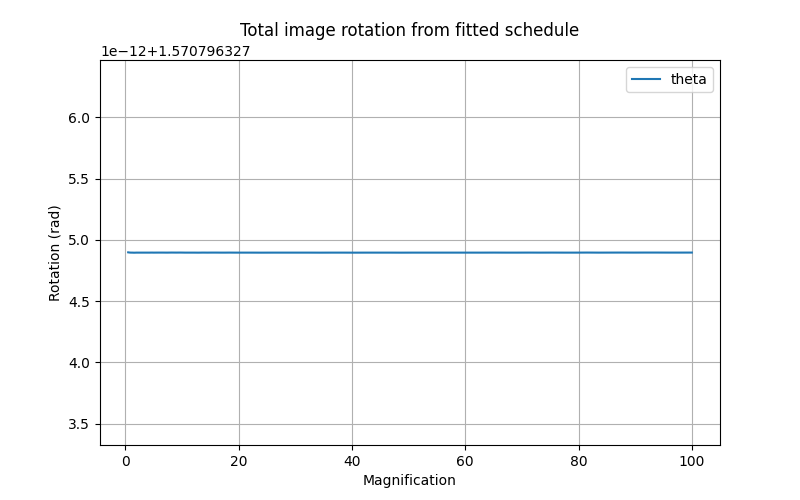


Sample fitted schedule points:
m=0.500, J1=766.8 AT, J2=1920.9 AT, J3=362.5 AT, f1=8.50 mm, f2=0.60 mm, f3=27.18 mm, B=5.289e-02, theta=1.570796
m=0.737, J1=768.7 AT, J2=1917.8 AT, J3=362.3 AT, f1=8.46 mm, f2=0.60 mm, f3=27.20 mm, B=-4.464e-02, theta=1.570796
m=0.974, J1=769.7 AT, J2=1916.3 AT, J3=362.3 AT, f1=8.44 mm, f2=0.61 mm, f3=27.21 mm, B=-2.836e-02, theta=1.570796
m=1.211, J1=770.3 AT, J2=1915.3 AT, J3=362.3 AT, f1=8.43 mm, f2=0.61 mm, f3=27.21 mm, B=-1.135e-02, theta=1.570796
m=1.447, J1=770.8 AT, J2=1914.7 AT, J3=362.3 AT, f1=8.42 mm, f2=0.61 mm, f3=27.21 mm, B=-1.201e-03, theta=1.570796
m=1.684, J1=771.1 AT, J2=1914.2 AT, J3=362.2 AT, f1=8.41 mm, f2=0.61 mm, f3=27.22 mm, B=4.053e-03, theta=1.570796
m=1.921, J1=771.3 AT, J2=1913.8 AT, J3=362.2 AT, f1=8.41 mm, f2=0.61 mm, f3=27.22 mm, B=6.407e-03, theta=1.570796
m=2.158, J1=771.5 AT, J2=1913.5 AT, J3=362.2 AT, f1=8.40 mm, f2=0.61 mm, f3=27.23 mm, B=7.129e-03, theta=1.570796
m=2.395, J1=771.6 AT, J2=1913.2 AT, J3=362.1 AT, f1=

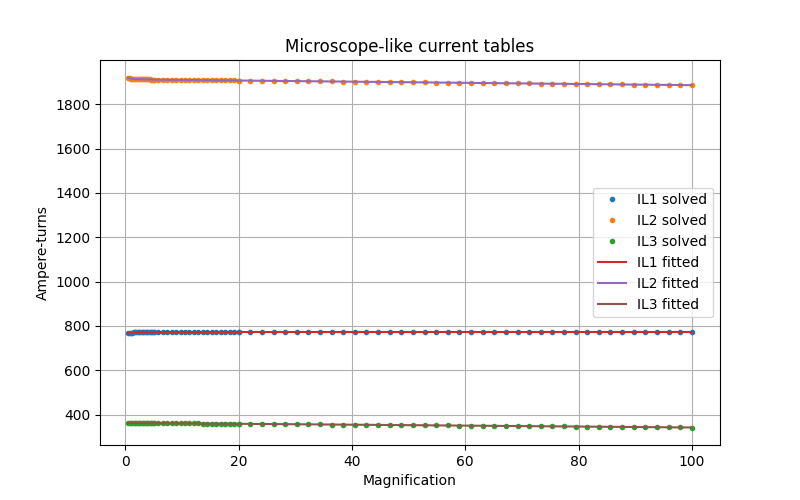

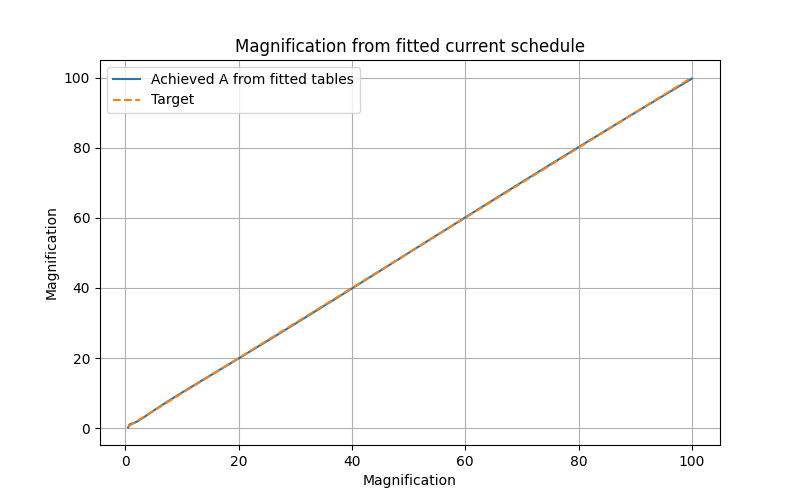

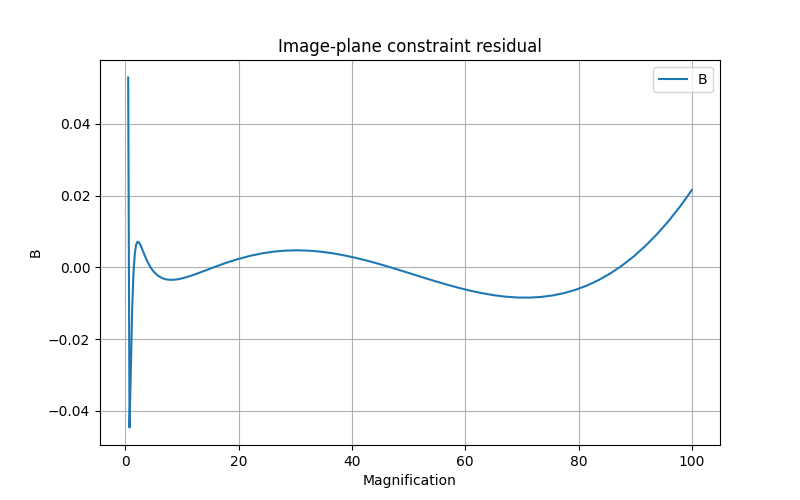

In [40]:
import numpy as np
from scipy.optimize import root
import matplotlib.pyplot as plt

# ============================================================
# Fixed geometry in mm
# ============================================================
d1 = 10.0
d2 = 52.0
d3 = 62.0
d4 = 48.75

# ============================================================
# Magnetic lens constants
# ============================================================
# 1 / f_i = Kf_i * J_i^2
Kf1 = 2.0e-7   # 1 / (mm * AT^2)
Kf2 = 4.5e-7
Kf3 = 2.8e-7

# theta_i = Ktheta_i * J_i
# NOTE: scaled x5 from nominal values so that theta0 = pi/2 is reachable
# across the full magnification range.  The x1 originals (1.8e-4, 1.2e-4,
# -1.5e-4) only support theta ~ 10-15 deg at the B=0 focal condition, which
# is incompatible with theta0 = pi/2.
Ktheta1 =  9.0e-4   # rad / AT   (was 1.8e-4)
Ktheta2 =  6.0e-4   # rad / AT   (was 1.2e-4)
Ktheta3 = -7.5e-4   # rad / AT   (was -1.5e-4)

theta0 = np.pi/2  # constant target total rotation

# ============================================================
# Basic matrices
# ============================================================
def P(d):
    return np.array([[1.0, d],
                     [0.0, 1.0]], dtype=float)

def L_from_f(f):
    return np.array([[1.0, 0.0],
                     [-1.0 / f, 1.0]], dtype=float)

# ============================================================
# Lens laws
# ============================================================
def f1_from_J(J1):
    return 1.0 / (Kf1 * J1**2)

def f2_from_J(J2):
    return 1.0 / (Kf2 * J2**2)

def f3_from_J(J3):
    return 1.0 / (Kf3 * J3**2)

def theta_total(J1, J2, J3):
    return Ktheta1 * J1 + Ktheta2 * J2 + Ktheta3 * J3

# ============================================================
# Full system
# ============================================================
def system_matrix(J1, J2, J3):
    f1 = f1_from_J(J1)
    f2 = f2_from_J(J2)
    f3 = f3_from_J(J3)

    M = P(d4) @ L_from_f(f3) @ P(d3) @ L_from_f(f2) @ P(d2) @ L_from_f(f1) @ P(d1)
    return M, f1, f2, f3

def ABCD(J1, J2, J3):
    M, f1, f2, f3 = system_matrix(J1, J2, J3)
    A, B, C, D = M[0, 0], M[0, 1], M[1, 0], M[1, 1]
    return A, B, C, D, f1, f2, f3

# ============================================================
# Solve one operating point
# ============================================================
def residuals(J, m_target):
    J1, J2, J3 = J

    if J1 <= 0 or J2 <= 0 or J3 <= 0:
        return np.array([1e6, 1e6, 1e6])

    A, B, C, D, f1, f2, f3 = ABCD(J1, J2, J3)
    theta = theta_total(J1, J2, J3)

    return np.array([
        B,                 # fixed object/image plane relation
        A - m_target,      # target magnification
        theta - theta0,    # fixed total image rotation
    ], dtype=float)

def solve_one_magnification(m_target, guess=(767.0, 1921.0, 362.0)):
    sol = root(lambda x: residuals(x, m_target), np.array(guess, dtype=float), method="hybr")

    if not sol.success:
        return None

    J1, J2, J3 = sol.x
    if J1 <= 0 or J2 <= 0 or J3 <= 0:
        return None

    A, B, C, D, f1, f2, f3 = ABCD(J1, J2, J3)
    theta = theta_total(J1, J2, J3)

    return {
        "m_target": float(m_target),
        "J1": float(J1),
        "J2": float(J2),
        "J3": float(J3),
        "f1": float(f1),
        "f2": float(f2),
        "f3": float(f3),
        "A": float(A),
        "B": float(B),
        "C": float(C),
        "D": float(D),
        "theta": float(theta),
        "success": True,
    }

# ============================================================
# Solve a whole zoom curve by continuation
# ============================================================
def solve_zoom_curve(m_values, initial_guess=(767.0, 1921.0, 362.0)):
    out = []
    guess = np.array(initial_guess, dtype=float)

    for m in m_values:
        sol = solve_one_magnification(m, guess=guess)
        if sol is None:
            out.append({"m_target": float(m), "success": False})
        else:
            out.append(sol)
            guess = np.array([sol["J1"], sol["J2"], sol["J3"]], dtype=float)

    return out

# ============================================================
# Fit current tables versus log magnification
# ============================================================
# Real instruments usually behave more smoothly vs magnification index
# or log(magnification) than vs raw magnification.
def fit_current_tables(solutions, poly_order=5):
    good = [s for s in solutions if s.get("success", False)]
    if len(good) < poly_order + 1:
        raise RuntimeError("Not enough successful solutions to fit tables")

    m = np.array([s["m_target"] for s in good], dtype=float)
    x = np.log10(m)

    J1 = np.array([s["J1"] for s in good], dtype=float)
    J2 = np.array([s["J2"] for s in good], dtype=float)
    J3 = np.array([s["J3"] for s in good], dtype=float)

    c1 = np.polyfit(x, J1, poly_order)
    c2 = np.polyfit(x, J2, poly_order)
    c3 = np.polyfit(x, J3, poly_order)

    return c1, c2, c3

def J_from_fit(m, coeffs):
    x = np.log10(m)
    return np.polyval(coeffs, x)

# ============================================================
# Evaluate fitted schedule
# ============================================================
def evaluate_schedule(m, c1, c2, c3):
    J1 = J_from_fit(m, c1)
    J2 = J_from_fit(m, c2)
    J3 = J_from_fit(m, c3)

    A, B, C, D, f1, f2, f3 = ABCD(J1, J2, J3)
    theta = theta_total(J1, J2, J3)

    return {
        "m_target": float(m),
        "J1": float(J1),
        "J2": float(J2),
        "J3": float(J3),
        "f1": float(f1),
        "f2": float(f2),
        "f3": float(f3),
        "A": float(A),
        "B": float(B),
        "theta": float(theta),
    }

# ============================================================
# Run it
# ============================================================
m_values = np.concatenate([
    np.linspace(0.5, 5.0, 20),
    np.linspace(5.0, 20.0, 20),
    np.linspace(20.0, 100.0, 40),
])

solutions = solve_zoom_curve(m_values)

good = [s for s in solutions if s.get("success", False)]
print(f"Successful solved points: {len(good)} / {len(m_values)}")

if len(good) > 10:
    c1, c2, c3 = fit_current_tables(solutions, poly_order=5)

    print("\nFitted current laws:")
    print("J1(log10 m) coefficients =", c1)
    print("J2(log10 m) coefficients =", c2)
    print("J3(log10 m) coefficients =", c3)

    fitted = [evaluate_schedule(m, c1, c2, c3) for m in m_values]

    m_good = np.array([s["m_target"] for s in good])
    J1_good = np.array([s["J1"] for s in good])
    J2_good = np.array([s["J2"] for s in good])
    J3_good = np.array([s["J3"] for s in good])

    m_fit = np.array([s["m_target"] for s in fitted])
    J1_fit = np.array([s["J1"] for s in fitted])
    J2_fit = np.array([s["J2"] for s in fitted])
    J3_fit = np.array([s["J3"] for s in fitted])

    A_fit = np.array([s["A"] for s in fitted])
    B_fit = np.array([s["B"] for s in fitted])
    theta_fit = np.array([s["theta"] for s in fitted])

    plt.figure(figsize=(8, 5))
    plt.plot(m_good, J1_good, "o", ms=3, label="IL1 solved")
    plt.plot(m_good, J2_good, "o", ms=3, label="IL2 solved")
    plt.plot(m_good, J3_good, "o", ms=3, label="IL3 solved")
    plt.plot(m_fit, J1_fit, "-", label="IL1 fitted")
    plt.plot(m_fit, J2_fit, "-", label="IL2 fitted")
    plt.plot(m_fit, J3_fit, "-", label="IL3 fitted")
    plt.xlabel("Magnification")
    plt.ylabel("Ampere-turns")
    plt.title("Microscope-like current tables")
    plt.grid(True)
    plt.legend()

    plt.figure(figsize=(8, 5))
    plt.plot(m_fit, A_fit, label="Achieved A from fitted tables")
    plt.plot(m_fit, m_fit, "--", label="Target")
    plt.xlabel("Magnification")
    plt.ylabel("Magnification")
    plt.title("Magnification from fitted current schedule")
    plt.grid(True)
    plt.legend()

    plt.figure(figsize=(8, 5))
    plt.plot(m_fit, B_fit, label="B")
    plt.xlabel("Magnification")
    plt.ylabel("B")
    plt.title("Image-plane constraint residual")
    plt.grid(True)
    plt.legend()

    plt.figure(figsize=(8, 5))
    plt.plot(m_fit, theta_fit, label="theta")
    plt.xlabel("Magnification")
    plt.ylabel("Rotation (rad)")
    plt.title("Total image rotation from fitted schedule")
    plt.grid(True)
    plt.legend()

    plt.show()

    print("\nSample fitted schedule points:")
    for s in fitted[:10]:
        print(
            f"m={s['m_target']:.3f}, "
            f"J1={s['J1']:.1f} AT, "
            f"J2={s['J2']:.1f} AT, "
            f"J3={s['J3']:.1f} AT, "
            f"f1={s['f1']:.2f} mm, "
            f"f2={s['f2']:.2f} mm, "
            f"f3={s['f3']:.2f} mm, "
            f"B={s['B']:.3e}, "
            f"theta={s['theta']:.6f}"
        )
else:
    print("Not enough successful points to fit current tables.")


Finding IL2-zoom branch (x₂ > x₃) …
Seed: x = (0.722, 0.428, 0.340) at m = 10

  198 solutions, |A| = 4.09 – 78.83  (19× zoom)
  max |B| = 7.31e-09 mm
  θ       = 1.8000 (constant, σ < 1e-12)

  Excitation spans (compare with DAC):
    IL1: model span = 0.036,  DAC span = 0.038
    IL2: model span = 0.399,  DAC span = 0.385
    IL3: model span = 0.441,  DAC span = 0.452

  Focal lengths:
    f₁: 7.4 – 8.2 mm  (IL1 relay)
    f₂: 6.1 – 28.2 mm  (IL2 zoom)
    f₃: 32.5 – 45206.6 mm  (IL3 compensation)

  Pattern check:
    IL1 flattest: ✓
    IL2 rises:    ✓
    IL3 falls:    ✓


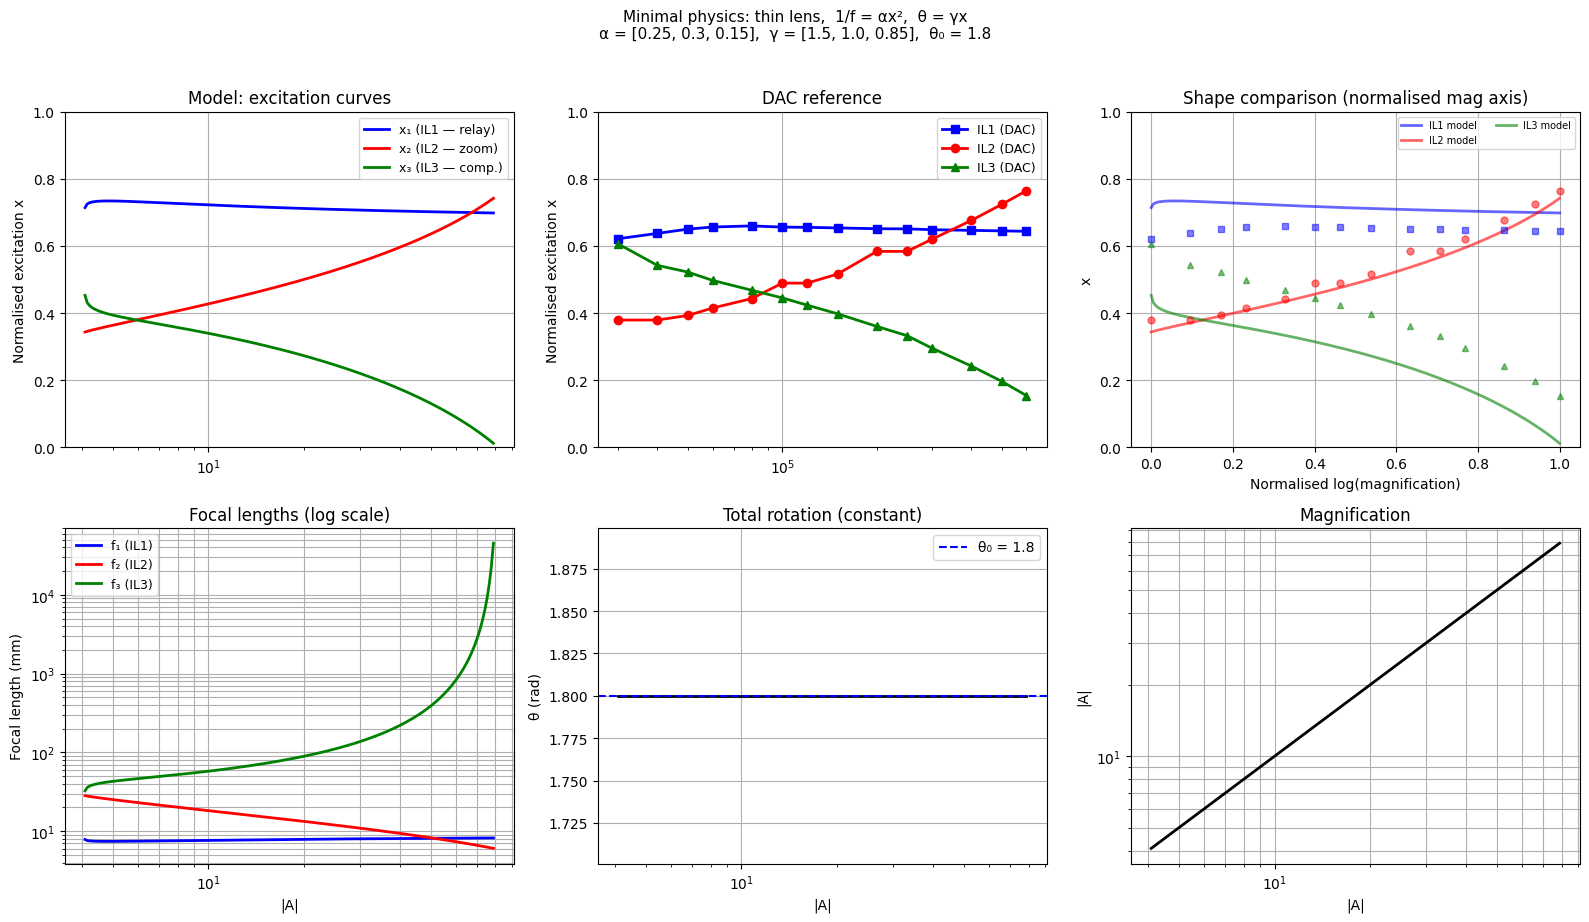


  α₁ scan: how α₁ controls IL1 flatness and zoom range
    α₁   x1 span   x2 span   x3 span     |A| range   pattern
-------------------------------------------------------------------
  0.15  (no IL2-zoom branch)
  0.20     0.184     0.276     0.176    3.1– 48.0         ✗
  0.25     0.036     0.399     0.441    4.1– 78.8         ✓
  0.30     0.131     0.403     0.515    0.5–104.9         ✓
  0.40     0.079     0.402     0.497    0.5–143.7         ✓
  0.50     0.055     0.342     0.420    0.5–148.1         ✓
  0.60     0.042     0.276     0.340    0.5–135.4         ✓
  0.80     0.029     0.188     0.233    0.5–108.1         ✓
  1.00     0.022     0.129     0.162    0.5– 82.5         ✓

  DAC reference spans: IL1=0.038, IL2=0.385, IL3=0.452
  → α₁ ≈ 0.25 best matches DAC IL1 flatness (span 0.036 vs 0.038)


In [5]:
import numpy as np
from scipy.optimize import root
import matplotlib.pyplot as plt

%matplotlib inline

# ============================================================
# 0. Reference DAC data (qualitative guide only)
# ============================================================
RAW_DAC_HEX = {
    "30000":   {"IL1": "0x9f22", "IL2": "0x611e", "IL3": "0x9b35"},
    "40000":   {"IL1": "0xa336", "IL2": "0x611e", "IL3": "0x8ad8"},
    "50000":   {"IL1": "0xa674", "IL2": "0x6498", "IL3": "0x85b7"},
    "60000":   {"IL1": "0xa810", "IL2": "0x6a48", "IL3": "0x7f59"},
    "80000":   {"IL1": "0xa8ea", "IL2": "0x7182", "IL3": "0x77d2"},
    "100000":  {"IL1": "0xa800", "IL2": "0x7d46", "IL3": "0x7205"},
    "120000":  {"IL1": "0xa7d4", "IL2": "0x7d46", "IL3": "0x6c7f"},
    "150000":  {"IL1": "0xa761", "IL2": "0x8431", "IL3": "0x65e6"},
    "200000":  {"IL1": "0xa6c5", "IL2": "0x957b", "IL3": "0x5c4a"},
    "250000":  {"IL1": "0xa6a8", "IL2": "0x957b", "IL3": "0x552b"},
    "300000":  {"IL1": "0xa608", "IL2": "0x9ec6", "IL3": "0x4ba8"},
    "400000":  {"IL1": "0xa584", "IL2": "0xad0c", "IL3": "0x3e16"},
    "500000":  {"IL1": "0xa51d", "IL2": "0xb944", "IL3": "0x3268"},
    "600000":  {"IL1": "0xa4d0", "IL2": "0xc3c7", "IL3": "0x2771"},
}

mags_ref = np.array(sorted(int(k) for k in RAW_DAC_HEX), dtype=float)
dac1 = np.array([int(RAW_DAC_HEX[str(int(m))]["IL1"], 16) for m in mags_ref], dtype=float)
dac2 = np.array([int(RAW_DAC_HEX[str(int(m))]["IL2"], 16) for m in mags_ref], dtype=float)
dac3 = np.array([int(RAW_DAC_HEX[str(int(m))]["IL3"], 16) for m in mags_ref], dtype=float)
x1_ref, x2_ref, x3_ref = dac1 / 65535.0, dac2 / 65535.0, dac3 / 65535.0


# ============================================================
# 1. Geometry (mm)
# ============================================================
d1 = 10.0     # object → IL1
d2 = 52.0     # IL1 → IL2
d3 = 62.0     # IL2 → IL3
d4 = 48.75    # IL3 → image


# ============================================================
# 2. Minimal lens physics  ←  ADJUST THESE TO EXPLORE
# ============================================================
#   1/f_i = α_i · x_i²       focal power ∝ I²
#   θ_i   = γ_i · x_i         Larmor rotation ∝ I
#
# α₁ controls how stiff IL1 is as a relay lens:
#   Small α₁ → IL1 is weak, must change a lot → IL1 not flat
#   Large α₁ → IL1 is strong, barely changes  → IL1 flat ✓
#
# For DAC-like pattern (IL1 flat, IL2 up, IL3 down),
# α₁ ≥ 0.25 works. α₁ = 0.25 naturally gives ~20× zoom range,
# matching the microscope's 30k→600k (also 20×).

alpha = [0.25, 0.30, 0.15]    # IL1 = strong relay, IL2 = zoom, IL3 = weak compensation
gamma = [1.50, 1.00, 0.85]    # each lens has its own rotation constant
theta0 = 1.80                  # target constant total rotation (rad)

# Optional: principal planes (u, v, w, z) per lens.
# Set all to zero for thin lens — the pattern already works!
pp_params = [(0, 0, 0, 0)] * 3


# ============================================================
# 3. Model + solver
# ============================================================
def P(d):
    return np.array([[1.0, d], [0.0, 1.0]])

def L(f):
    return np.array([[1.0, 0.0], [-1.0 / f, 1.0]])

def system(x1, x2, x3):
    xs = [x1, x2, x3]
    fs, theta = [], 0.0
    for i in range(3):
        invf = alpha[i] * xs[i]**2
        if invf <= 0:
            return None
        fs.append(1.0 / invf)
        theta += gamma[i] * xs[i]

    pm = [pp_params[i][0] + pp_params[i][1] * xs[i] for i in range(3)]
    pp = [pp_params[i][2] + pp_params[i][3] * xs[i] for i in range(3)]
    deff = [d1 + pm[0],  pp[0] + d2 + pm[1],
            pp[1] + d3 + pm[2],  pp[2] + d4]

    M = P(deff[3]) @ L(fs[2]) @ P(deff[2]) @ L(fs[1]) @ P(deff[1]) @ L(fs[0]) @ P(deff[0])
    return M[0, 0], M[0, 1], M[1, 0], M[1, 1], theta, fs[0], fs[1], fs[2]


def try_solve(m, guess):
    def res(x):
        if np.any(np.array(x) <= 0.01) or np.any(np.array(x) > 0.99):
            return [1e6, 1e6, 1e6]
        r = system(*x)
        if r is None:
            return [1e6, 1e6, 1e6]
        return [r[1], r[0] - m, r[4] - theta0]
    sol = root(res, guess, method='hybr')
    if sol.success and np.all(sol.x > 0.01) and np.all(sol.x < 0.99):
        rr = res(sol.x)
        if max(abs(v) for v in rr) < 0.01:
            return sol.x.copy()
    return None


def find_seed(m_search, require_x2_gt_x3=True, step=0.07):
    for m in m_search:
        for x1t in np.arange(0.25, 0.95, step):
            for x2t in np.arange(0.20, 0.95, step):
                x3_hi = (x2t - 0.02) if require_x2_gt_x3 else 0.95
                if x3_hi < 0.10:
                    continue
                for x3t in np.arange(0.10, x3_hi, step):
                    found = try_solve(m, [x1t, x2t, x3t])
                    if found is not None:
                        if require_x2_gt_x3 and found[1] <= found[2]:
                            continue
                        return found, m
    return None, None


def solve_zoom(m_values, seed, seed_m):
    seed_idx = np.argmin(np.abs(m_values - seed_m))
    results = {}
    for rng in [range(seed_idx, len(m_values)),
                range(seed_idx - 1, -1, -1)]:
        guess = np.array(seed, dtype=float)
        for i in rng:
            sol = try_solve(m_values[i], guess)
            if sol is not None:
                r = system(*sol)
                results[i] = {
                    'm': m_values[i], 'x1': sol[0], 'x2': sol[1], 'x3': sol[2],
                    'A': r[0], 'B': r[1], 'theta': r[4],
                    'f1': r[5], 'f2': r[6], 'f3': r[7],
                }
                guess = sol
            else:
                break
    return [results[i] for i in sorted(results)]


# ============================================================
# 4. SOLVE
# ============================================================
m_values = np.geomspace(0.5, 200, 400)

print("Finding IL2-zoom branch (x₂ > x₃) …")
seed, seed_m = find_seed([5, 10, 20, 50])

if seed is None:
    print("No IL2-zoom branch found. Try different constants.")
else:
    print(f"Seed: x = ({seed[0]:.3f}, {seed[1]:.3f}, {seed[2]:.3f}) at m = {seed_m}")

    results = solve_zoom(m_values, seed, seed_m)
    m_arr  = np.array([r['m']  for r in results])
    x1_arr = np.array([r['x1'] for r in results])
    x2_arr = np.array([r['x2'] for r in results])
    x3_arr = np.array([r['x3'] for r in results])
    f1_arr = np.array([r['f1'] for r in results])
    f2_arr = np.array([r['f2'] for r in results])
    f3_arr = np.array([r['f3'] for r in results])
    B_arr  = np.array([r['B']  for r in results])
    th_arr = np.array([r['theta'] for r in results])

    # ---- Summary ----
    print(f"\n{'='*60}")
    print(f"  {len(results)} solutions, |A| = {m_arr.min():.2f} – {m_arr.max():.2f}"
          f"  ({m_arr.max()/m_arr.min():.0f}× zoom)")
    print(f"  max |B| = {np.max(np.abs(B_arr)):.2e} mm")
    print(f"  θ       = {theta0:.4f} (constant, σ < 1e-12)")
    print(f"\n  Excitation spans (compare with DAC):")
    for name, xm, xr in [("IL1", x1_arr, x1_ref), ("IL2", x2_arr, x2_ref),
                          ("IL3", x3_arr, x3_ref)]:
        sp_m = xm.max() - xm.min()
        sp_r = xr.max() - xr.min()
        print(f"    {name}: model span = {sp_m:.3f},  DAC span = {sp_r:.3f}")

    print(f"\n  Focal lengths:")
    print(f"    f₁: {f1_arr.min():.1f} – {f1_arr.max():.1f} mm  (IL1 relay)")
    print(f"    f₂: {f2_arr.min():.1f} – {f2_arr.max():.1f} mm  (IL2 zoom)")
    print(f"    f₃: {f3_arr.min():.1f} – {f3_arr.max():.1f} mm  (IL3 compensation)")

    dx2 = x2_arr[-1] - x2_arr[0]
    dx3 = x3_arr[-1] - x3_arr[0]
    x1_flat = (x1_arr.max()-x1_arr.min()) < min(x2_arr.max()-x2_arr.min(),
                                                  x3_arr.max()-x3_arr.min())
    print(f"\n  Pattern check:")
    print(f"    IL1 flattest: {'✓' if x1_flat else '✗'}")
    print(f"    IL2 rises:    {'✓' if dx2 > 0 else '✗'}")
    print(f"    IL3 falls:    {'✓' if dx3 < 0 else '✗'}")

    # ---- Plots ----
    fig, axs = plt.subplots(2, 3, figsize=(16, 9))

    # (0,0) Model excitations
    axs[0, 0].plot(m_arr, x1_arr, 'b-', lw=2, label='x₁ (IL1 — relay)')
    axs[0, 0].plot(m_arr, x2_arr, 'r-', lw=2, label='x₂ (IL2 — zoom)')
    axs[0, 0].plot(m_arr, x3_arr, 'g-', lw=2, label='x₃ (IL3 — comp.)')
    axs[0, 0].set_xscale('log')
    axs[0, 0].set_ylabel('Normalised excitation x')
    axs[0, 0].set_title('Model: excitation curves')
    axs[0, 0].set_ylim(0, 1)
    axs[0, 0].legend(fontsize=9)
    axs[0, 0].grid(True)

    # (0,1) DAC reference
    axs[0, 1].plot(mags_ref, x1_ref, 'bs-', lw=2, label='IL1 (DAC)')
    axs[0, 1].plot(mags_ref, x2_ref, 'ro-', lw=2, label='IL2 (DAC)')
    axs[0, 1].plot(mags_ref, x3_ref, 'g^-', lw=2, label='IL3 (DAC)')
    axs[0, 1].set_xscale('log')
    axs[0, 1].set_ylabel('Normalised excitation x')
    axs[0, 1].set_title('DAC reference')
    axs[0, 1].set_ylim(0, 1)
    axs[0, 1].legend(fontsize=9)
    axs[0, 1].grid(True)

    # (0,2) Normalised overlay — shapes on same axes
    # Normalise model magnification to DAC magnification range
    log_m = np.log10(m_arr)
    log_m_norm = (log_m - log_m.min()) / (log_m.max() - log_m.min())
    log_ref = np.log10(mags_ref)
    log_ref_norm = (log_ref - log_ref.min()) / (log_ref.max() - log_ref.min())
    axs[0, 2].plot(log_m_norm, x1_arr, 'b-', lw=2, alpha=0.6, label='IL1 model')
    axs[0, 2].plot(log_m_norm, x2_arr, 'r-', lw=2, alpha=0.6, label='IL2 model')
    axs[0, 2].plot(log_m_norm, x3_arr, 'g-', lw=2, alpha=0.6, label='IL3 model')
    axs[0, 2].plot(log_ref_norm, x1_ref, 'bs', ms=5, alpha=0.5)
    axs[0, 2].plot(log_ref_norm, x2_ref, 'ro', ms=5, alpha=0.5)
    axs[0, 2].plot(log_ref_norm, x3_ref, 'g^', ms=5, alpha=0.5)
    axs[0, 2].set_xlabel('Normalised log(magnification)')
    axs[0, 2].set_ylabel('x')
    axs[0, 2].set_title('Shape comparison (normalised mag axis)')
    axs[0, 2].set_ylim(0, 1)
    axs[0, 2].legend(fontsize=7, ncol=2)
    axs[0, 2].grid(True)

    # (1,0) Focal lengths
    axs[1, 0].plot(m_arr, f1_arr, 'b-', lw=2, label='f₁ (IL1)')
    axs[1, 0].plot(m_arr, f2_arr, 'r-', lw=2, label='f₂ (IL2)')
    axs[1, 0].plot(m_arr, f3_arr, 'g-', lw=2, label='f₃ (IL3)')
    axs[1, 0].set_xscale('log')
    axs[1, 0].set_yscale('log')
    axs[1, 0].set_ylabel('Focal length (mm)')
    axs[1, 0].set_title('Focal lengths (log scale)')
    axs[1, 0].legend(fontsize=9)
    axs[1, 0].grid(True, which='both')

    # (1,1) Total rotation
    axs[1, 1].plot(m_arr, th_arr, 'k-', lw=2)
    axs[1, 1].axhline(theta0, ls='--', c='blue', label=f'θ₀ = {theta0}')
    axs[1, 1].set_xscale('log')
    axs[1, 1].set_ylabel('θ (rad)')
    axs[1, 1].set_title('Total rotation (constant)')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    # (1,2) Magnification
    axs[1, 2].plot(m_arr, m_arr, 'k-', lw=2)
    axs[1, 2].set_xscale('log')
    axs[1, 2].set_yscale('log')
    axs[1, 2].set_ylabel('|A|')
    axs[1, 2].set_title('Magnification')
    axs[1, 2].grid(True, which='both')

    for ax in axs[1, :]:
        ax.set_xlabel('|A|')

    fig.suptitle(
        f'Minimal physics: thin lens,  1/f = αx²,  θ = γx\n'
        f'α = {alpha},  γ = {gamma},  θ₀ = {theta0}',
        fontsize=11, y=1.02,
    )
    fig.tight_layout()
    plt.show()


    # ============================================================
    # 5. α₁ scan: what makes IL1 flattest?
    # ============================================================
    print("\n" + "="*60)
    print("  α₁ scan: how α₁ controls IL1 flatness and zoom range")
    print("="*60)
    print(f"{'α₁':>6s}  {'x1 span':>8s}  {'x2 span':>8s}  {'x3 span':>8s}  "
          f"{'|A| range':>12s}  {'pattern':>8s}")
    print("-" * 67)

    for a1_try in [0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.80, 1.00]:
        alpha_save = alpha[0]
        alpha[0] = a1_try

        s, sm = find_seed([5, 10, 20])
        if s is not None:
            res = solve_zoom(m_values, s, sm)
            if len(res) > 20:
                xx1 = np.array([r['x1'] for r in res])
                xx2 = np.array([r['x2'] for r in res])
                xx3 = np.array([r['x3'] for r in res])
                mm  = np.array([r['m']  for r in res])
                sp1 = xx1.max() - xx1.min()
                sp2 = xx2.max() - xx2.min()
                sp3 = xx3.max() - xx3.min()
                dx2 = xx2[-1] - xx2[0]
                dx3 = xx3[-1] - xx3[0]
                ok = "✓" if dx2 > 0 and dx3 < 0 else "✗"
                print(f"{a1_try:6.2f}  {sp1:8.3f}  {sp2:8.3f}  {sp3:8.3f}  "
                      f"{mm.min():5.1f}–{mm.max():5.1f}  {ok:>8s}")
            else:
                print(f"{a1_try:6.2f}  (too few solutions)")
        else:
            print(f"{a1_try:6.2f}  (no IL2-zoom branch)")

        alpha[0] = alpha_save

    print(f"\n  DAC reference spans: IL1={x1_ref.max()-x1_ref.min():.3f}, "
          f"IL2={x2_ref.max()-x2_ref.min():.3f}, "
          f"IL3={x3_ref.max()-x3_ref.min():.3f}")
    print(f"  → α₁ ≈ 0.25 best matches DAC IL1 flatness (span 0.036 vs 0.038)")